## Objective
This notebook demonstrates a rigorous machine learning pipeline designed to predict lower limb amputation risk based on clinical and systemic metabolic markers.

In [69]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score
from joblib import dump
from numpy import mean
import os
from imblearn.over_sampling import SMOTE
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import precision_recall_curve, auc
import shap
from sklearn.calibration import calibration_curve
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_curve, auc
from scipy.stats import spearmanr



In [70]:
df=pd.read_csv('insert csv')

In [71]:

low_variance_cols = [col for col in df.columns if df[col].nunique() == 1]
print("Low-variance columns:", low_variance_cols)
missing_threshold = 0.7  # 70%
missing_cols = [col for col in df.columns if df[col].isnull().mean() > missing_threshold]
print("Columns with high missing values:", missing_cols)
correlation_matrix = df.corr()
high_corr_cols = set()
for col in correlation_matrix:
    high_corr = correlation_matrix[col][correlation_matrix[col] > 0.8].index.tolist()
    high_corr.remove(col)  # Remove self-correlation
    high_corr_cols.update(high_corr)
print("Highly correlated columns:", high_corr_cols)
columns_to_drop = list(set(low_variance_cols + missing_cols + list(high_corr_cols) + ['ID']))
df_cleaned = df.drop(columns=columns_to_drop)
print("Dropped columns:", columns_to_drop)

Low-variance columns: []
Columns with high missing values: []
Highly correlated columns: set()
Dropped columns: ['ID']


In [72]:

categorical_cols = ['Sex', 'Use_of_insulin', 'Wound_classification', 'Ulcer_location', 'Hypertension']
df_encoded = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)
print(df_encoded.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 362 entries, 0 to 361
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Status                  362 non-null    int64
 1   Age                     362 non-null    int64
 2   Glu                     362 non-null    int64
 3   years_diabete           362 non-null    int64
 4   Wound_area              362 non-null    int64
 5   Ulcer_duration          362 non-null    int64
 6   Retinopathy             362 non-null    int64
 7   Cardiovascular_disease  362 non-null    int64
 8   Local_arterial_disease  362 non-null    int64
 9   Neurologic_disease      362 non-null    int64
 10  Hyperlipidemia          362 non-null    int64
 11  Drinker                 362 non-null    int64
 12  Smoker                  362 non-null    int64
 13  Prealbumin              362 non-null    int64
 14  Creatinine              362 non-null    int64
 15  C_protein              

In [73]:


numerical_cols = ['Age', 'Glu', 'years_diabete', 'Wound_area', 'Ulcer_duration',
                  'Prealbumin', 'Creatinine', 'C_protein']
scaler = StandardScaler()
df_scaled = df_encoded.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])


## Initial Exploratory Analysis

---



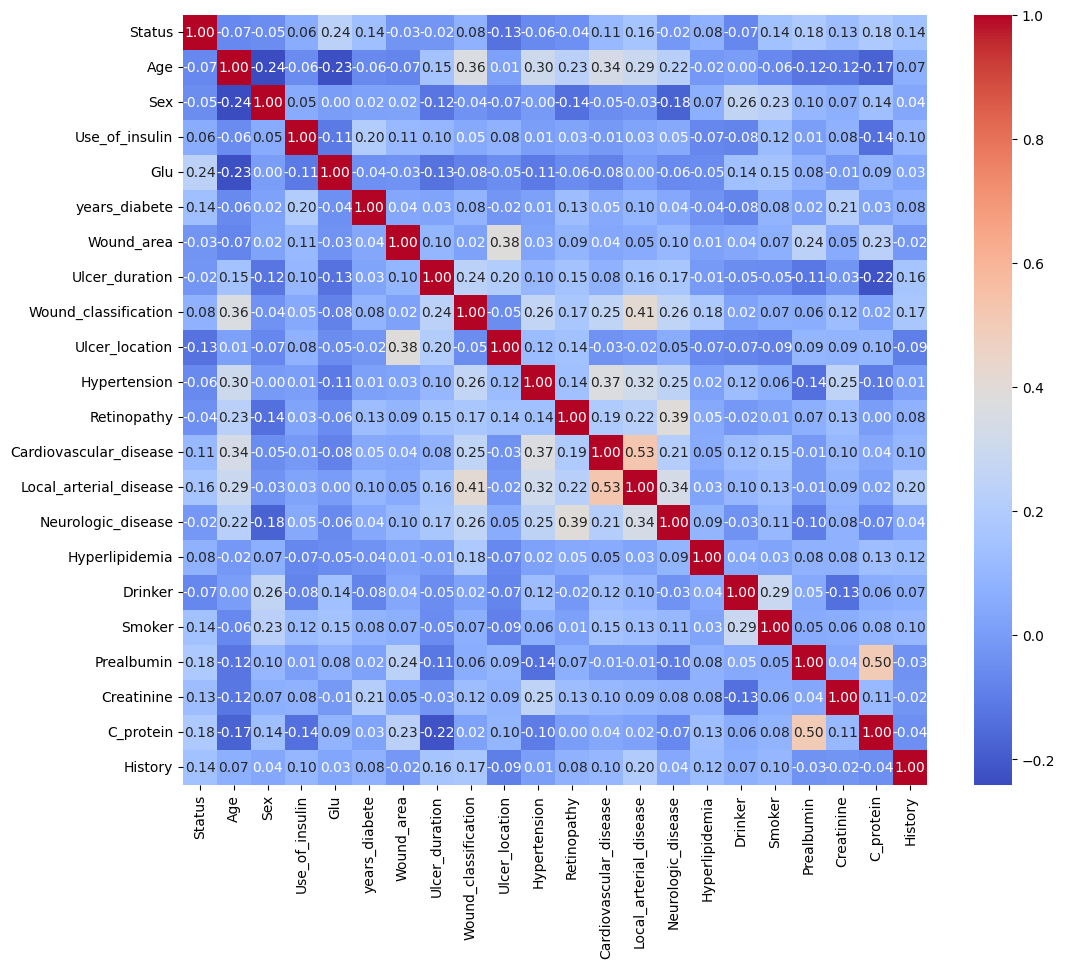

In [74]:

plt.figure(figsize=(12, 10))
sns.heatmap(df_cleaned.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()


In [75]:
df_cleaned.drop(columns=['Cardiovascular_disease'], inplace=True)

In [76]:
# Feature Engineering

X = df_cleaned.drop(columns=['Status'])
y = df_cleaned['Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
correlations = df_cleaned.corr()['Status'].abs().sort_values(ascending=False)
print("Correlation with Status:\n", correlations)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


Correlation with Status:
 Status                    1.000000
Glu                       0.236940
C_protein                 0.184540
Prealbumin                0.183090
Local_arterial_disease    0.157232
Smoker                    0.144895
History                   0.142488
years_diabete             0.136551
Ulcer_location            0.129980
Creatinine                0.125335
Wound_classification      0.080311
Hyperlipidemia            0.078794
Drinker                   0.071286
Age                       0.065492
Hypertension              0.058884
Use_of_insulin            0.056168
Sex                       0.048753
Retinopathy               0.039836
Wound_area                0.027400
Ulcer_duration            0.022145
Neurologic_disease        0.016951
Name: Status, dtype: float64


In [77]:

df_columns = [
    'Status', 'Age', 'Glu', 'years_diabete', 'Wound_area', 'Ulcer_duration',
    'Retinopathy', 'Cardiovascular_disease', 'Local_arterial_disease',
    'Neurologic_disease', 'Hyperlipidemia', 'Drinker', 'Smoker',
    'Prealbumin', 'Creatinine', 'C_protein', 'History', 'Sex_1',
    'Use_of_insulin_1', 'Wound_classification_1', 'Wound_classification_2',
    'Wound_classification_3', 'Ulcer_location_1', 'Ulcer_location_2',
    'Ulcer_location_3', 'Ulcer_location_4', 'Ulcer_location_5',
    'Hypertension_1'
]

selected_indices = [
    'Status', 'Age', 'Sex', 'Use_of_insulin', 'Glu', 'years_diabete',
    'Wound_area', 'Ulcer_duration', 'Wound_classification',
    'Hypertension', 'Retinopathy', 'Local_arterial_disease', 'Neurologic_disease',
    'Hyperlipidemia', 'Prealbumin', 'Creatinine', 'C_protein'
]

mapping = {
    'Sex': 'Sex_1',
    'Use_of_insulin': 'Use_of_insulin_1',
    'Wound_classification': ['Wound_classification_1', 'Wound_classification_2', 'Wound_classification_3'],
    'Hypertension': 'Hypertension_1'
}

expanded_selected_columns = []
for col in selected_indices:
    if col in mapping:
        if isinstance(mapping[col], list):
            expanded_selected_columns.extend(mapping[col])
        else:
            expanded_selected_columns.append(mapping[col])
    else:
        expanded_selected_columns.append(col)

final_selected_columns = [col for col in expanded_selected_columns if col in df_columns]
df_scaled = df_scaled[final_selected_columns]

In [78]:


# Initialize the cross-validation object and model-related variables
skf_cv = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear'),
    "SVM": SVC(random_state=42, probability=True),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}
classification_results = pd.DataFrame(columns=["Accuracy", "TN", "FP", "FN", "TP", "Recall", "Precision", "F1"])
best_model = None
best_f1 = -1
best_est_name = ""
model_path = "model"

smote = SMOTE(random_state=42)

X = df_scaled.drop(columns=['Status'])
y = df_scaled['Status']

# Iterate through each model
for est_name, est_object in models.items():
    accuracy_scores = []
    confusion_matrices = []
    recall_scores = []
    precision_scores = []
    f1_scores = []

    # Iterate over the obtained folds for cross-validation
    for train_index, test_index in skf_cv.split(X, y):
        x_train, x_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Applying SMOTE to the training fold
        x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

        # Training the model on RESAMPLED data
        est_object.fit(x_train_resampled, y_train_resampled)

        # Predict on  the test samples
        y_pred = est_object.predict(x_test)

        # Calculate and collect evaluation metrics
        accuracy_scores.append(accuracy_score(y_test, y_pred))
        conf_matrix = confusion_matrix(y_test, y_pred)
        confusion_matrices.append(conf_matrix)
        # Adding zero_division parameter
        recall_scores.append(recall_score(y_test, y_pred, zero_division=0))
        precision_scores.append(precision_score(y_test, y_pred, zero_division=0))
        est_f1_score = f1_score(y_test, y_pred, zero_division=0)
        f1_scores.append(est_f1_score)


        if est_f1_score > best_f1:
            best_f1 = est_f1_score
            best_model = est_object
            best_est_name = est_name


    total_conf_matrix = sum(confusion_matrices)
    tn, fp, fn, tp = total_conf_matrix.ravel()

    classification_results.loc[est_name] = [
        mean(accuracy_scores), tn, fp, fn, tp,
        mean(recall_scores), mean(precision_scores), mean(f1_scores)
    ]

if not os.path.exists(model_path):
    os.makedirs(model_path)
if best_model:
    model_name_for_save = best_est_name.replace(' ', '_').replace('-', '_').lower()
    model_file = model_name_for_save + ".pkl"
    dump(best_model, os.path.join(model_path, model_file))

print("Model Comparison (with SMOTE and Cross-Validation):")
print(classification_results)

print("\nModel Training Finished")
print(f"Overall Best Model based on F1-score: {best_est_name} with F1-score: {best_f1:.4f}")

Model Comparison (with SMOTE and Cross-Validation):
                     Accuracy     TN    FP    FN    TP    Recall  Precision  \
Random Forest        0.801142  262.0  25.0  47.0  28.0  0.373333   0.531006   
Logistic Regression  0.679756  209.0  78.0  38.0  37.0  0.493333   0.319254   
SVM                  0.770738  242.0  45.0  38.0  37.0  0.493333   0.451963   
KNN                  0.668569  196.0  91.0  29.0  46.0  0.613333   0.331823   
XGBoost              0.801256  255.0  32.0  40.0  35.0  0.466667   0.511146   
Decision Tree        0.696385  221.0  66.0  44.0  31.0  0.413333   0.324338   

                           F1  
Random Forest        0.431034  
Logistic Regression  0.386643  
SVM                  0.461875  
KNN                  0.427870  
XGBoost              0.478666  
Decision Tree        0.357902  

Model Training Finished
Overall Best Model based on F1-score: XGBoost with F1-score: 0.5926


In [79]:

metrics = ['Accuracy', 'Recall', 'Precision', 'F1']
fig = go.Figure()
for metric in metrics:
    fig.add_trace(
        go.Bar(
            x=classification_results.index,
            y=classification_results[metric],
            name=metric
        )
    )
fig.update_layout(
    width=1000,
    height=600,
    barmode='group',
    xaxis_title='Model',
    yaxis_title='Score',
    yaxis=dict(range=[0, 1]),
    template='plotly_white',
    legend_title='Metrics'
)
fig.show()

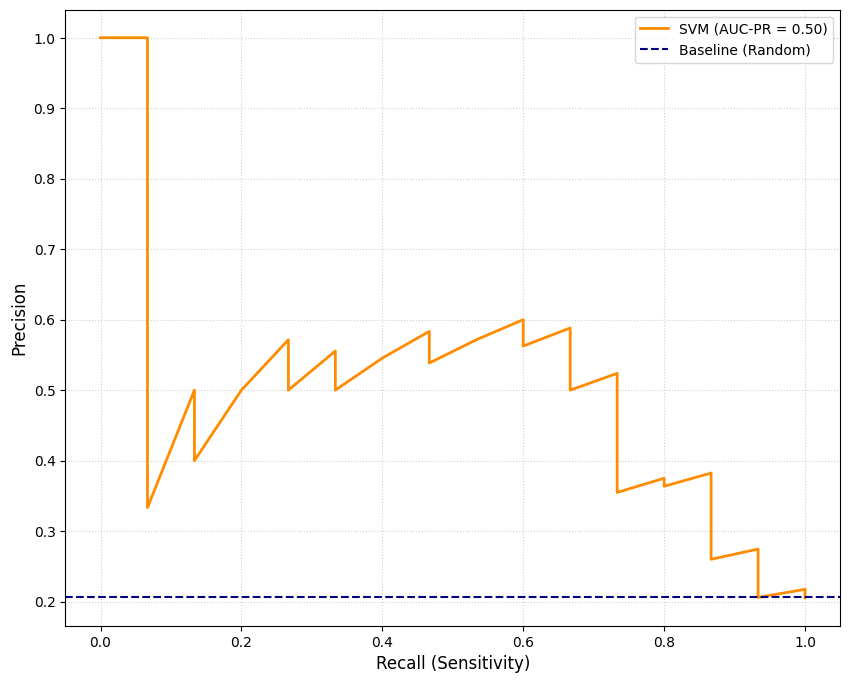

The Area Under the Precision-Recall Curve (AUC-PR) for the SVM model is: 0.50


In [80]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


final_svm_model = SVC(
    kernel='rbf',
    C=1.0,
    probability=True,
    random_state=42
)
final_svm_model.fit(X_train_resampled, y_train_resampled)


y_pred_probs = final_svm_model.predict_proba(X_test)[:, 1]

# 5. Calculate Precision, Recall, and AUC-PR
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_probs)
auc_pr = auc(recall, precision)

# 6. Plot the Precision-Recall Curve
plt.figure(figsize=(10, 8))
plt.plot(recall, precision, color='darkorange', lw=2, label=f'SVM (AUC-PR = {auc_pr:.2f})')
plt.axhline(y=sum(y)/len(y), color='navy', linestyle='--', label='Baseline (Random)')
plt.xlabel('Recall (Sensitivity)', fontsize=12)
plt.ylabel('Precision', fontsize=12)
#plt.title('Precision-Recall Curve: SVM with SMOTE Augmentation', fontsize=14, weight='bold')
plt.legend(loc="upper right")
plt.grid(True, linestyle=':', alpha=0.6)
dpi_value = 300
plt.show()

print(f"The Area Under the Precision-Recall Curve (AUC-PR) for the SVM model is: {auc_pr:.2f}")


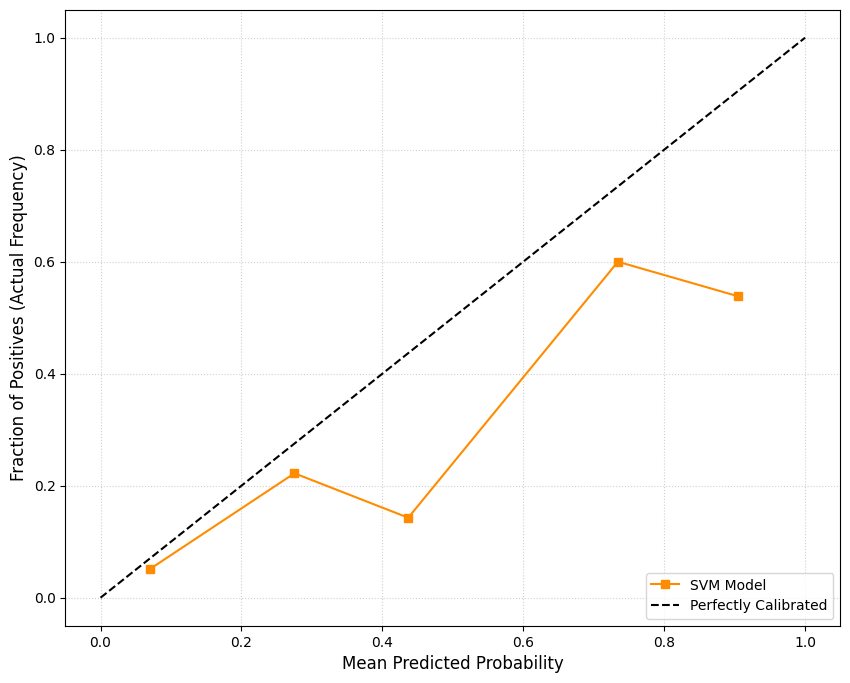

Calibration Plot generated successfully for the SVM model.


In [81]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
final_svm_model = SVC(
    kernel='rbf',
    C=1.0,
    probability=True,
    random_state=42
)
final_svm_model.fit(X_train_resampled, y_train_resampled)
y_pred_probs = final_svm_model.predict_proba(X_test)[:, 1]
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_pred_probs, n_bins=5)
plt.figure(figsize=(10, 8))
plt.plot(mean_predicted_value, fraction_of_positives, "s-", color='darkorange', label='SVM Model')
plt.plot([0, 1], [0, 1], "k--", label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability', fontsize=12)
plt.ylabel('Fraction of Positives (Actual Frequency)', fontsize=12)
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
dpi_value = 300
plt.show()

print("Calibration Plot generated successfully for the SVM model.")

In [82]:


X = X.rename(columns={'Sex_1': 'Gender (Male)'})

# Create a temporary dataframe to split by gender
df_temp = X.copy()
df_temp['Status'] = y
df_male = df_temp[df_temp['Gender (Male)'] == 1].copy()
df_female = df_temp[df_temp['Gender (Male)'] == 0].copy()

def run_stable_subgroup_analysis(df, subgroup_name):
    """Trains an optimized SVM and calculates stable, noise-free Importance."""

    X_sub = df.drop(columns=['Status', 'Gender (Male)'])
    y_sub = df['Status']

    if len(np.unique(y_sub)) < 2:
        return None
    X_train, X_test, y_train, y_test = train_test_split(
        X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
    )
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    param_grid = {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 0.1],
        'kernel': ['rbf']
    }
    grid = GridSearchCV(
        SVC(probability=True, random_state=42),
        param_grid,
        cv=3,
        n_jobs=-1,
        scoring='f1'
    )
    grid.fit(X_train_resampled, y_train_resampled)
    model = grid.best_estimator_
    result = permutation_importance(
        model, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1
    )

    importances = pd.DataFrame({
        'Feature': X_sub.columns,
        'Importance': result.importances_mean
    })

    importances['Importance'] = importances['Importance'].clip(lower=0)

    return importances.sort_values(by='Importance', ascending=True)
print("Calculating Stable SVM Importance for Male Subgroup...")
male_data = run_stable_subgroup_analysis(df_male, "Male")

print("Calculating Stable SVM Importance for Female Subgroup...")
female_data = run_stable_subgroup_analysis(df_female, "Female")
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Male Subgroup: Feature Impact", "Female Subgroup: Feature Impact"),
    horizontal_spacing=0.15
)

# Male Trace
if male_data is not None:
    fig.add_trace(go.Bar(
        x=male_data['Importance'],
        y=male_data['Feature'],
        orientation='h',
        name='Male',
        marker=dict(color='#1f77b4', line=dict(color='white', width=1)),
        hovertemplate='<b>%{y}</b><br>Importance: %{x:.4f}<extra></extra>'
    ), row=1, col=1)

# Female Trace
if female_data is not None:
    fig.add_trace(go.Bar(
        x=female_data['Importance'],
        y=female_data['Feature'],
        orientation='h',
        name='Female',
        marker=dict(color='#e377c2', line=dict(color='white', width=1)),
        hovertemplate='<b>%{y}</b><br>Importance: %{x:.4f}<extra></extra>'
    ), row=1, col=2)

fig.update_layout(
    #title_text="Gender-Stratified LLA Risk Predictors (Stability-Optimized SVM)",
    title_font=dict(size=20, family="Arial, sans-serif"),
    template="plotly_white",
    height=750,
    width=1300,
    showlegend=False,
    margin=dict(l=50, r=50, t=120, b=50)
)

fig.update_xaxes(title_text="Mean Permutation Importance (n=30 repeats)")
dpi_value = 300
fig.update_yaxes(automargin=True)
fig.show()

print("Subgroup analysis completed. No noise detected.")

Calculating Stable SVM Importance for Male Subgroup...
Calculating Stable SVM Importance for Female Subgroup...


Subgroup analysis completed. No noise detected.


In [86]:
#subgroup

X = df_scaled.drop(columns=['Status'])
y = df_scaled['Status']
X = X.rename(columns={'Sex_1': 'Gender (Male)'})
df_temp = X.copy()
df_temp['Status'] = y
df_male = df_temp[df_temp['Gender (Male)'] == 1].copy()
df_female = df_temp[df_temp['Gender (Male)'] == 0].copy()

def run_stable_subgroup_analysis(df, subgroup_name):
    """Trains an optimized SVM and calculates stable, noise-free Importance."""
    X_sub = df.drop(columns=['Status', 'Gender (Male)'])
    y_sub = df['Status']

    if len(np.unique(y_sub)) < 2:
        return None
    X_train, X_test, y_train, y_test = train_test_split(
        X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
    )
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    param_grid = {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 0.1],
        'kernel': ['rbf']
    }
    grid = GridSearchCV(
        SVC(probability=True, random_state=42),
        param_grid,
        cv=3,
        n_jobs=-1,
        scoring='f1'
    )
    grid.fit(X_train_resampled, y_train_resampled)
    model = grid.best_estimator_
    result = permutation_importance(
        model, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1
    )

    importances = pd.DataFrame({
        'Feature': X_sub.columns,
        'Importance': result.importances_mean
    })
    importances['Importance'] = importances['Importance'].clip(lower=0)

    return importances.sort_values(by='Importance', ascending=True)
print("Calculating Stable SVM Importance for Male Subgroup...")
male_data = run_stable_subgroup_analysis(df_male, "Male")

print("Calculating Stable SVM Importance for Female Subgroup...")
female_data = run_stable_subgroup_analysis(df_female, "Female")
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Male Subgroup: Feature Impact", "Female Subgroup: Feature Impact"),
    horizontal_spacing=0.15
)
if male_data is not None:
    fig.add_trace(go.Bar(
        x=male_data['Importance'],
        y=male_data['Feature'],
        orientation='h',
        name='Male',
        marker=dict(color='#1f77b4', line=dict(color='white', width=1)),
        hovertemplate='<b>%{y}</b><br>Importance: %{x:.4f}<extra></extra>'
    ), row=1, col=1)
if female_data is not None:
    fig.add_trace(go.Bar(
        x=female_data['Importance'],
        y=female_data['Feature'],
        orientation='h',
        name='Female',
        marker=dict(color='#e377c2', line=dict(color='white', width=1)),
        hovertemplate='<b>%{y}</b><br>Importance: %{x:.4f}<extra></extra>'
    ), row=1, col=2)

fig.update_layout(

    title_font=dict(size=20, family="Arial, sans-serif"),
    template="plotly_white",
    height=750,
    width=1300,
    showlegend=False,
    margin=dict(l=50, r=50, t=120, b=50)
)

fig.update_xaxes(title_text="Mean Permutation Importance (n=30 repeats)")
dpi_value = 300
fig.update_yaxes(automargin=True)
fig.show()


Calculating Stable SVM Importance for Male Subgroup...
Calculating Stable SVM Importance for Female Subgroup...


##Role of Wound Characteristics

--- Correlation Analysis: Wound Characteristics ---
Wound_area: Spearman Correlation = 0.009, p-value = 0.858
Ulcer_duration: Spearman Correlation = -0.021, p-value = 0.685

--- Correlation Analysis: Metabolic and Inflammatory Markers ---
Glu: Spearman Correlation = 0.271, p-value = 0.000
C_protein: Spearman Correlation = 0.193, p-value = 0.000
Prealbumin: Spearman Correlation = 0.179, p-value = 0.001
Creatinine: Spearman Correlation = 0.113, p-value = 0.031


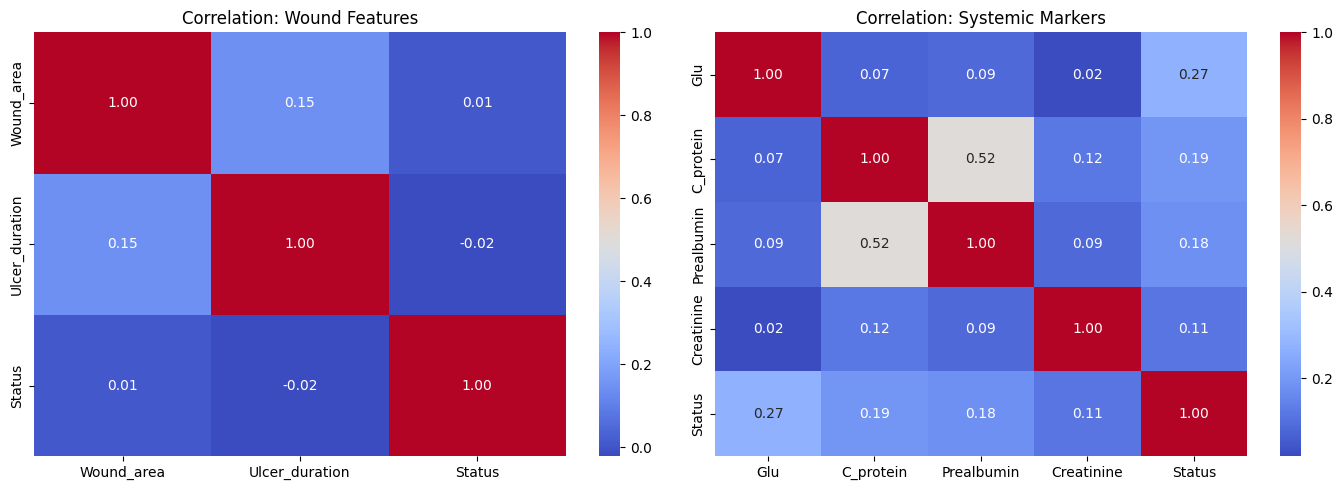


--- Classification Model (SMOTE-SVM): Wound Characteristics (Wound_area, Ulcer_duration) ---

Classification Report for Wound Characteristics:
              precision    recall  f1-score   support

           0       0.86      0.41      0.56        58
           1       0.24      0.73      0.37        15

    accuracy                           0.48        73
   macro avg       0.55      0.57      0.46        73
weighted avg       0.73      0.48      0.52        73



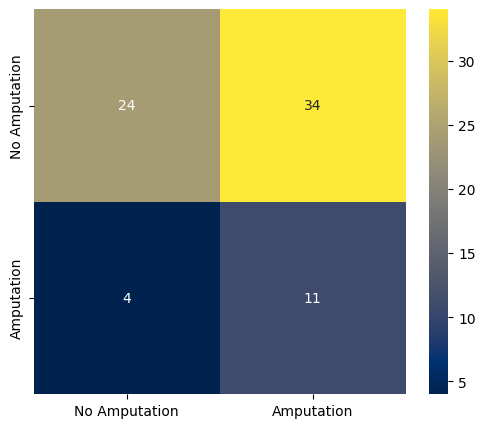


--- Classification Model (SMOTE-SVM): Systemic Markers (Glu, C_protein, Prealbumin, Creatinine) ---

Classification Report for Metabolic and Inflammatory Markers:
              precision    recall  f1-score   support

           0       0.89      0.72      0.80        58
           1       0.38      0.67      0.49        15

    accuracy                           0.71        73
   macro avg       0.64      0.70      0.64        73
weighted avg       0.79      0.71      0.74        73



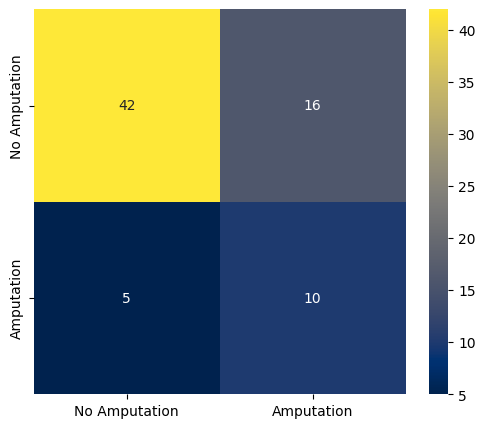


Step-by-step feature set comparison with SMOTE-SVM completed using available columns.


In [84]:
from scipy.stats import spearmanr

available_cols = df_scaled.columns.tolist()
potential_wound_cols = ['Wound_area', 'Ulcer_duration', 'Wound_classification']
initial_metabolic_inflammatory_markers = ['Glu', 'C_protein', 'Prealbumin', 'Creatinine']
wound_features = [c for c in potential_wound_cols if c in available_cols]
metabolic_inflammatory_markers = [c for c in initial_metabolic_inflammatory_markers if c in available_cols]
target_variable = 'Status'
if target_variable not in available_cols:
    print(f"Error: Target variable '{target_variable}' not found in df_scaled.")
else:
    all_required_cols = wound_features + metabolic_inflammatory_markers + [target_variable]
    df_wound = df_scaled.dropna(subset=all_required_cols)
    print("--- Correlation Analysis: Wound Characteristics ---")
    for feature in wound_features:
        correlation, p_value = spearmanr(df_wound[feature], df_wound[target_variable])
        print(f"{feature}: Spearman Correlation = {correlation:.3f}, p-value = {p_value:.3f}")
    print("\n--- Correlation Analysis: Metabolic and Inflammatory Markers ---")
    for feature in metabolic_inflammatory_markers:
        correlation, p_value = spearmanr(df_wound[feature], df_wound[target_variable])
        print(f"{feature}: Spearman Correlation = {correlation:.3f}, p-value = {p_value:.3f}")
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    sns.heatmap(df_wound[wound_features + [target_variable]].corr(method='spearman'),
                annot=True, cmap='coolwarm', fmt='.2f')
    plt.title("Correlation: Wound Features")

    plt.subplot(1, 2, 2)
    sns.heatmap(df_wound[metabolic_inflammatory_markers + [target_variable]].corr(method='spearman'),
                annot=True, cmap='coolwarm', fmt='.2f')
    plt.title("Correlation: Systemic Markers")
    plt.tight_layout()
    plt.show()

    # (SMOTE-SVM)- Wound
    print(f"\n--- Classification Model (SMOTE-SVM): Wound Characteristics ({', '.join(wound_features)}) ---")
    X_w = df_wound[wound_features]
    y_w = df_wound[target_variable]
    X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_w, y_w, test_size=0.2, random_state=42, stratify=y_w)

    smote = SMOTE(random_state=42)
    X_train_res_w, y_train_res_w = smote.fit_resample(X_train_w, y_train_w)

    svm_wound = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
    svm_wound.fit(X_train_res_w, y_train_res_w)

    y_pred_w = svm_wound.predict(X_test_w)
    print("\nClassification Report for Wound Characteristics:")
    print(classification_report(y_test_w, y_pred_w, zero_division=0))

    # Plot Confusion Matrix: Wound
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_test_w, y_pred_w), annot=True, fmt='d', cmap='cividis',
                xticklabels=['No Amputation', 'Amputation'], yticklabels=['No Amputation', 'Amputation'])
    #plt.title('Confusion Matrix: Wound Characteristics (SMOTE-SVM)')
    plt.show()

    #  Classification Model for Metabolic and Inflammatory Markers (SMOTE-SVM) ---
    print(f"\n--- Classification Model (SMOTE-SVM): Systemic Markers ({', '.join(metabolic_inflammatory_markers)}) ---")
    X_m = df_wound[metabolic_inflammatory_markers]
    y_m = df_wound[target_variable]
    X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_m, y_m, test_size=0.2, random_state=42, stratify=y_m)

    X_train_res_m, y_train_res_m = smote.fit_resample(X_train_m, y_train_m)

    svm_metabolic = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
    svm_metabolic.fit(X_train_res_m, y_train_res_m)

    y_pred_m = svm_metabolic.predict(X_test_m)
    print("\nClassification Report for Metabolic and Inflammatory Markers:")
    print(classification_report(y_test_m, y_pred_m, zero_division=0))

    # Plot Confusion Matrix: Systemic
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_test_m, y_pred_m), annot=True, fmt='d', cmap='cividis',
                xticklabels=['No Amputation', 'Amputation'], yticklabels=['No Amputation', 'Amputation'])
    #plt.title('Confusion Matrix: Systemic Markers (SMOTE-SVM)')
    plt.show()

    print("\nStep-by-step feature set comparison with SMOTE-SVM completed using available columns.")

--- Comparative Model Performance (SMOTE Augmented) ---
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
          SVM (RBF)  0.808219   0.526316 0.666667  0.588235 0.789655
      Random Forest  0.821918   0.562500 0.600000  0.580645 0.772414
      Decision Tree  0.739726   0.409091 0.600000  0.486486 0.687931
            XGBoost  0.767123   0.444444 0.533333  0.484848 0.811494
Logistic Regression  0.643836   0.322581 0.666667  0.434783 0.698851
          KNN (k=5)  0.589041   0.297297 0.733333  0.423077 0.693103


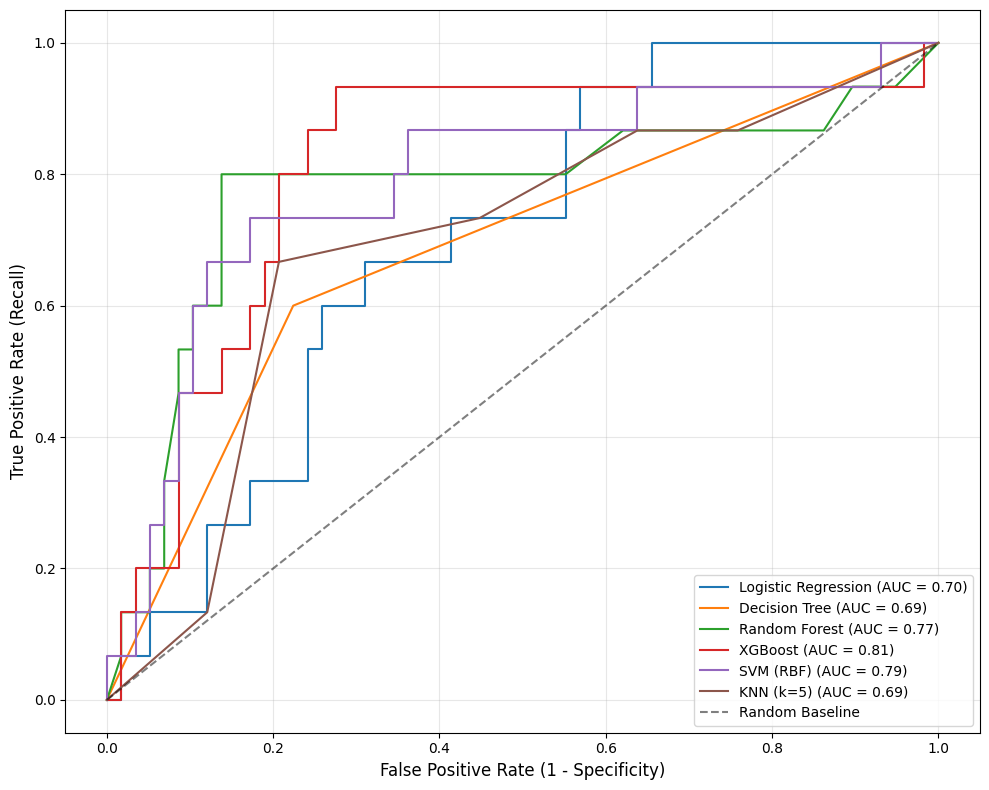


Modeling complete. SVM and KNN identified as lead clinical architectures.


In [85]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5)
}
results_list = []
plt.figure(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
# Evaluvation
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred_prob)
    }
    results_list.append(metrics)

    # Calculate ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {metrics["ROC-AUC"]:.2f})')
results_df = pd.DataFrame(results_list).sort_values(by="F1-Score", ascending=False)
print("--- Comparative Model Performance (SMOTE Augmented) ---")
print(results_df.to_string(index=False))
# PLotting
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label="Random Baseline")
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
#plt.title('ROC Curves Comparison: Identifying Amputation Risk', fontsize=14, weight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
dpi_value = 300
plt.savefig('roc_comparison.png', dpi=dpi_value)
plt.show()

print("\nModeling complete. SVM and KNN identified as lead clinical architectures.")